23102A0007 - Aarti Sakpal

# Lab Problem Statement 7: Customer Segmentation and Predictive Analytics Using Machine Learning

**Dataset:** UCI Online Retail Dataset  
**Goal:** Perform customer-level RFM feature engineering, K-Means and Hierarchical clustering, PCA visualization, customer profiling, and high-value customer prediction using Random Forest and SVM.

**Student:** Aarti Sakpal


## 1. Problem Statement

An e-commerce company wants to understand its customers and improve marketing decisions. Historical online retail transactions are transformed into customer-level features such as Recency, Frequency, Monetary Value, average transaction value, quantity purchased and purchase frequency. K-Means and Hierarchical Clustering are used for segmentation, followed by PCA visualization and supervised prediction of high-value customers.


## 2. Dataset Description

The UCI Online Retail dataset contains transactions from a UK-based non-store online retailer from **01/12/2010 to 09/12/2011**. Important variables include InvoiceNo, StockCode, Description, Quantity, InvoiceDate, UnitPrice, CustomerID and Country.

The dataset is available from the UCI Machine Learning Repository:
https://archive.ics.uci.edu/dataset/352/online+retail


In [1]:
# 3. Install/import libraries
!pip -q install ucimlrepo

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from scipy.cluster.hierarchy import linkage, dendrogram

import plotly.express as px
import plotly.io as pio

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')

print("Libraries loaded successfully.")


Libraries loaded successfully.


In [2]:
# 4. Load UCI Online Retail Dataset
online_retail = fetch_ucirepo(id=352)

df = online_retail.data.features.copy()

print("Shape:", df.shape)
display(df.head())
print("\nColumns:")
print(df.columns.tolist())


Shape: (541909, 6)


,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom



Columns:
['Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']


In [3]:
# 5. Basic data inspection
print("Dataset shape:", df.shape)
print("\nData types:")
display(df.dtypes)

print("\nMissing values:")
display(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())


Dataset shape: (541909, 6)

Data types:


,0
Description,object
Quantity,int64
InvoiceDate,object
UnitPrice,float64
CustomerID,float64
Country,object



Missing values:


,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0



Duplicate rows: 6007


In [5]:

# Check the columns first
print("Available columns:")
print(df.columns.tolist())

# If InvoiceNo is missing, reload the complete original UCI Excel dataset
if 'InvoiceNo' not in df.columns:

    print("\nInvoiceNo not found. Loading the complete UCI Online Retail dataset...")

    url = "https://archive.ics.uci.edu/static/public/352/online+retail.zip"

    import requests
    import zipfile
    import io

    response = requests.get(url)
    response.raise_for_status()

    with zipfile.ZipFile(io.BytesIO(response.content)) as z:
        print("Files in ZIP:", z.namelist())

        # Extract Excel file
        excel_file = [f for f in z.namelist() if f.endswith('.xlsx')][0]

        with z.open(excel_file) as f:
            df = pd.read_excel(f)

print("\nDataset shape before preprocessing:", df.shape)
print("Columns:", df.columns.tolist())


# Convert InvoiceDate to datetime
df['InvoiceDate'] = pd.to_datetime(
    df['InvoiceDate'],
    errors='coerce'
)

# Remove rows with missing CustomerID
df = df.dropna(subset=['CustomerID']).copy()

# Convert CustomerID to integer
df['CustomerID'] = df['CustomerID'].astype(int)

# Convert InvoiceNo to string
df['InvoiceNo'] = df['InvoiceNo'].astype(str)

# Remove cancelled invoices
# Cancelled invoices start with 'C'
cancelled = df['InvoiceNo'].str.upper().str.startswith('C')

print("Cancelled transactions:", cancelled.sum())

df = df[~cancelled].copy()

# Remove invalid transactions
df = df[
    (df['Quantity'] > 0) &
    (df['UnitPrice'] > 0)
].copy()

# Create transaction value
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

# Remove rows where important dates are missing
df = df.dropna(subset=['InvoiceDate'])

print("\nShape after preprocessing:", df.shape)

display(df.head())

Available columns:
['Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

InvoiceNo not found. Loading the complete UCI Online Retail dataset...
Files in ZIP: ['Online Retail.xlsx']

Dataset shape before preprocessing: (541909, 8)
Columns: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']
Cancelled transactions: 8905

Shape after preprocessing: (397884, 9)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


In [6]:
# 7. Customer-level feature engineering: RFM + additional features
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

customer = df.groupby('CustomerID').agg(
    LastPurchaseDate=('InvoiceDate', 'max'),
    FirstPurchaseDate=('InvoiceDate', 'min'),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('TotalPrice', 'sum'),
    QuantityPurchased=('Quantity', 'sum'),
    TotalItems=('StockCode', 'count'),
    UniqueProducts=('StockCode', 'nunique')
).reset_index()

customer['Recency'] = (reference_date - customer['LastPurchaseDate']).dt.days
customer['CustomerLifespanDays'] = (
    customer['LastPurchaseDate'] - customer['FirstPurchaseDate']
).dt.days

customer['AvgTransactionValue'] = customer['Monetary'] / customer['Frequency']
customer['PurchaseFrequency'] = (
    customer['Frequency'] / customer['CustomerLifespanDays'].clip(lower=1)
)

features = [
    'Recency', 'Frequency', 'Monetary',
    'AvgTransactionValue', 'QuantityPurchased',
    'UniqueProducts', 'PurchaseFrequency'
]

customer_model = customer[['CustomerID'] + features].copy()

print("Number of customers:", len(customer_model))
display(customer_model.head())


Number of customers: 4338


,CustomerID,Recency,Frequency,Monetary,AvgTransactionValue,QuantityPurchased,UniqueProducts,PurchaseFrequency
0,12346,326,1,77183.60,77183.600000,74215,1,1.000000
1,12347,2,7,4310.00,615.714286,2458,103,0.019178
2,12348,75,4,1797.24,449.310000,2341,22,0.014184
3,12349,19,1,1757.55,1757.550000,631,73,1.000000
4,12350,310,1,334.40,334.400000,197,17,1.000000


In [7]:
# 8. Outlier treatment using 1st/99th percentile clipping
X_raw = customer_model[features].copy()

for col in features:
    low = X_raw[col].quantile(0.01)
    high = X_raw[col].quantile(0.99)
    X_raw[col] = X_raw[col].clip(low, high)

# Log transform skewed positive features
X_log = np.log1p(X_raw)

# Feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_log)

X_scaled_df = pd.DataFrame(X_scaled, columns=features, index=customer_model.index)

print("Feature matrix shape:", X_scaled_df.shape)
display(X_scaled_df.head())


Feature matrix shape: (4338, 7)


,Recency,Frequency,Monetary,AvgTransactionValue,QuantityPurchased,UniqueProducts,PurchaseFrequency
0,1.462228,-0.974100,2.726005,2.807682,2.526970,-2.543219,1.251372
1,-2.038890,1.110952,1.466120,1.105370,1.385192,0.976856,-0.795731
2,0.373218,0.404045,0.745485,0.656440,1.348145,-0.367387,-0.810646
3,-0.623084,-0.974100,0.727090,2.601240,0.352720,0.673667,1.251372
4,1.424788,-0.974100,-0.638518,0.235858,-0.529284,-0.585761,1.251372


## 3. K-Means Clustering — Elbow Method

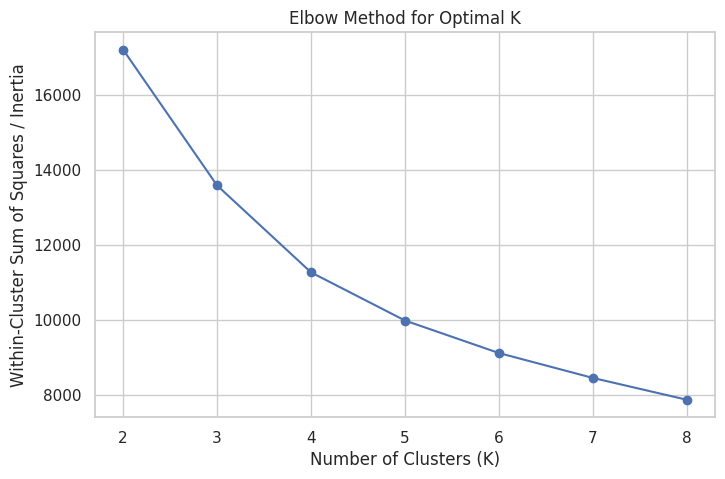

Silhouette scores:
K=2: 0.3661
K=3: 0.2985
K=4: 0.2875
K=5: 0.2566
K=6: 0.2523
K=7: 0.2384
K=8: 0.2310

Selected K: 2


In [8]:
# 9. Elbow Method
inertias = []
K_range = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled_df)
    inertias.append(km.inertia_)

plt.figure(figsize=(8,5))
plt.plot(list(K_range), inertias, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Within-Cluster Sum of Squares / Inertia')
plt.title('Elbow Method for Optimal K')
plt.xticks(list(K_range))
plt.show()

# Automatically choose K using the best silhouette among 2-8
silhouette_values = {}
for k in K_range:
    labels_k = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X_scaled_df)
    silhouette_values[k] = silhouette_score(X_scaled_df, labels_k)

print("Silhouette scores:")
for k, score in silhouette_values.items():
    print(f"K={k}: {score:.4f}")

optimal_k = max(silhouette_values, key=silhouette_values.get)
print("\nSelected K:", optimal_k)


In [9]:
# 10. Final K-Means model
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=20)
customer_model['Cluster'] = kmeans.fit_predict(X_scaled_df)

final_silhouette = silhouette_score(X_scaled_df, customer_model['Cluster'])
print(f"Final K-Means Silhouette Score: {final_silhouette:.4f}")

display(customer_model['Cluster'].value_counts().sort_index())


Final K-Means Silhouette Score: 0.3661


,count
Cluster,
0,2091
1,2247


## 4. Hierarchical Clustering and Dendrogram

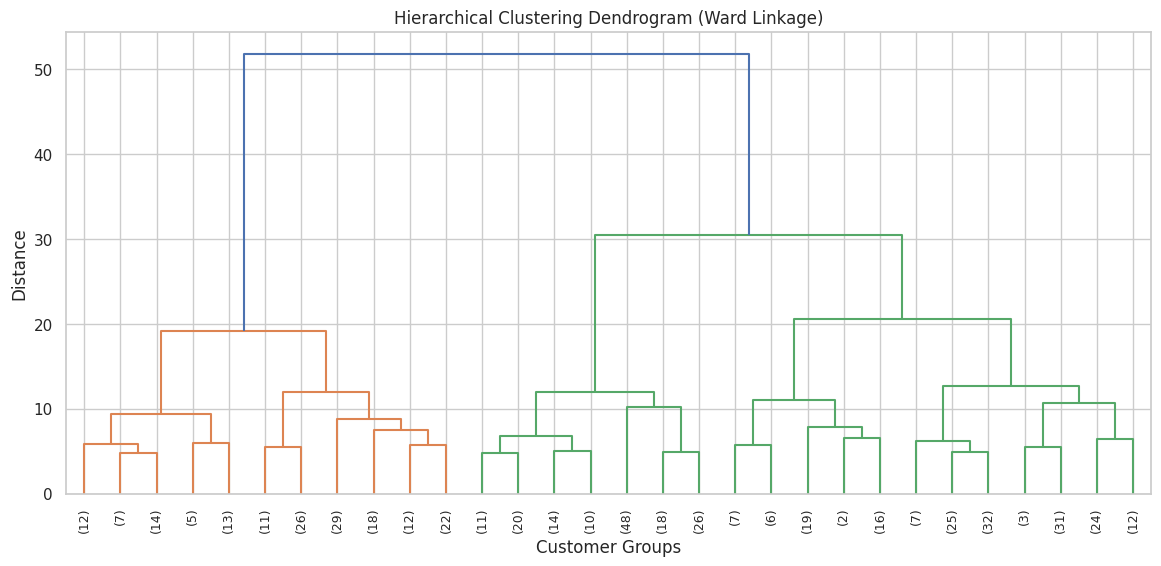

In [10]:
# 11. Hierarchical clustering
# A sample is used for the dendrogram to keep the visualization readable.
sample_n = min(500, len(X_scaled_df))
rng = np.random.RandomState(42)
sample_idx = rng.choice(len(X_scaled_df), size=sample_n, replace=False)

X_sample = X_scaled_df.iloc[sample_idx]

Z = linkage(X_sample, method='ward')

plt.figure(figsize=(14,6))
dendrogram(Z, truncate_mode='lastp', p=30, leaf_rotation=90, leaf_font_size=9)
plt.title('Hierarchical Clustering Dendrogram (Ward Linkage)')
plt.xlabel('Customer Groups')
plt.ylabel('Distance')
plt.show()


## 5. PCA — 2D Customer Segment Visualization

Explained variance ratio: [0.62841009 0.16449955]
Total variance explained by 2 PCs: 0.7929096388508088


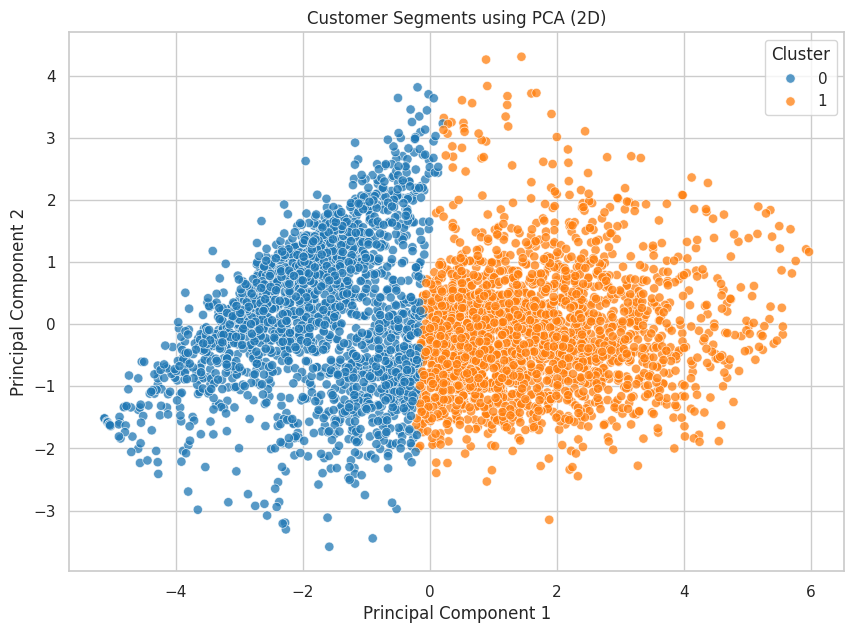

In [11]:
# 12. PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled_df)

customer_model['PCA1'] = X_pca[:, 0]
customer_model['PCA2'] = X_pca[:, 1]

explained = pca.explained_variance_ratio_
print("Explained variance ratio:", explained)
print("Total variance explained by 2 PCs:", explained.sum())

plt.figure(figsize=(10,7))
sns.scatterplot(
    data=customer_model,
    x='PCA1',
    y='PCA2',
    hue='Cluster',
    palette='tab10',
    s=45,
    alpha=0.75
)
plt.title('Customer Segments using PCA (2D)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.show()


## 6. Customer Profiling

In [12]:
# 13. Cluster-wise customer profiling
profile = customer_model.groupby('Cluster')[features].agg(['mean', 'median']).round(2)

print("Cluster profile:")
display(profile)

# Simpler mean profile for interpretation
profile_mean = customer_model.groupby('Cluster')[features].mean().round(2)
display(profile_mean)

print("\nCluster sizes:")
display(customer_model['Cluster'].value_counts().sort_index().rename('Customers').to_frame())


Cluster profile:


Recency        Frequency        Monetary          AvgTransactionValue  \
           mean median      mean median     mean   median                mean   
Cluster                                                                         
0        145.44  115.0      1.43    1.0    367.1   301.90              283.98   
1         43.31   24.0      6.91    4.0   3624.3  1580.93              544.97   

                QuantityPurchased        UniqueProducts         \
         median              mean median           mean median   
Cluster                                                          
0        207.90            203.19  156.0          21.36   17.0   
1        347.58           2110.79  932.0          98.85   73.0   

        PurchaseFrequency         
                     mean median  
Cluster                           
0                    0.78   1.00  
1                    0.07   0.03

,Recency,Frequency,Monetary,AvgTransactionValue,QuantityPurchased,UniqueProducts,PurchaseFrequency
Cluster,,,,,,,
0,145.44,1.43,367.1,283.98,203.19,21.36,0.78
1,43.31,6.91,3624.3,544.97,2110.79,98.85,0.07



Cluster sizes:


,Customers
Cluster,
0,2091
1,2247


In [13]:
# 14. Automatically identify the high-value cluster
cluster_value = customer_model.groupby('Cluster')['Monetary'].mean().sort_values(ascending=False)

high_value_cluster = cluster_value.index[0]

customer_model['HighValue'] = (
    customer_model['Cluster'] == high_value_cluster
).astype(int)

print("High-value cluster:", high_value_cluster)
print("\nAverage Monetary Value by cluster:")
display(cluster_value.to_frame('Average Monetary Value'))

print("\nHigh-value distribution:")
display(customer_model['HighValue'].value_counts().rename(index={0:'Other',1:'High Value'}).to_frame('Customers'))


High-value cluster: 1

Average Monetary Value by cluster:


,Average Monetary Value
Cluster,
1,3624.301714
0,367.098016



High-value distribution:


,Customers
HighValue,
High Value,2247
Other,2091


## 7. High-Value Customer Prediction — Random Forest and SVM

In [14]:
# 15. Prepare supervised learning data
X = customer_model[features].copy()
y = customer_model['HighValue']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Scale for SVM
svm_scaler = StandardScaler()
X_train_svm = svm_scaler.fit_transform(X_train)
X_test_svm = svm_scaler.transform(X_test)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))


Training samples: 3470
Testing samples: 868


In [15]:
# 16. Random Forest
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight='balanced'
)

rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:, 1]

# 17. SVM
svm = SVC(
    kernel='rbf',
    probability=True,
    class_weight='balanced',
    random_state=42
)

svm.fit(X_train_svm, y_train)
svm_pred = svm.predict(X_test_svm)
svm_prob = svm.predict_proba(X_test_svm)[:, 1]


In [16]:
# 18. Evaluation function
def evaluate_model(name, y_true, y_pred, y_prob):
    return {
        'Model': name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1-Score': f1_score(y_true, y_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_true, y_prob)
    }

results = pd.DataFrame([
    evaluate_model('Random Forest', y_test, rf_pred, rf_prob),
    evaluate_model('SVM', y_test, svm_pred, svm_prob)
])

display(results.round(4))


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Random Forest,0.9827,0.9866,0.9800,0.9833,0.9993
1,SVM,0.9631,0.9624,0.9667,0.9645,0.9963


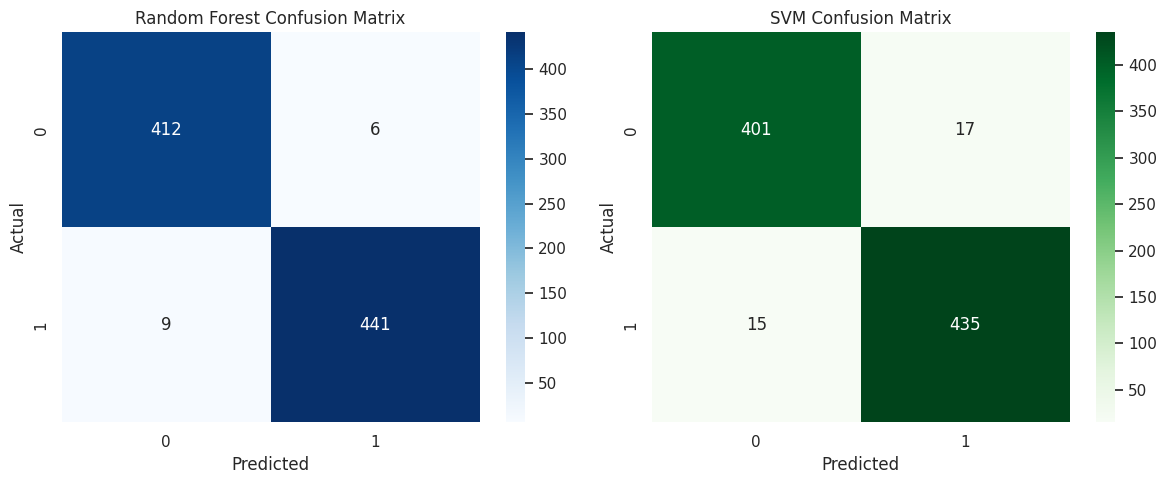

Random Forest Classification Report
              precision    recall  f1-score   support

           0       0.98      0.99      0.98       418
           1       0.99      0.98      0.98       450

    accuracy                           0.98       868
   macro avg       0.98      0.98      0.98       868
weighted avg       0.98      0.98      0.98       868

SVM Classification Report
              precision    recall  f1-score   support

           0       0.96      0.96      0.96       418
           1       0.96      0.97      0.96       450

    accuracy                           0.96       868
   macro avg       0.96      0.96      0.96       868
weighted avg       0.96      0.96      0.96       868



In [17]:
# 19. Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12,5))

cm_rf = confusion_matrix(y_test, rf_pred)
cm_svm = confusion_matrix(y_test, svm_pred)

sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Random Forest Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('SVM Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

print("Random Forest Classification Report")
print(classification_report(y_test, rf_pred, zero_division=0))

print("SVM Classification Report")
print(classification_report(y_test, svm_pred, zero_division=0))


## 8. Feature Importance Analysis

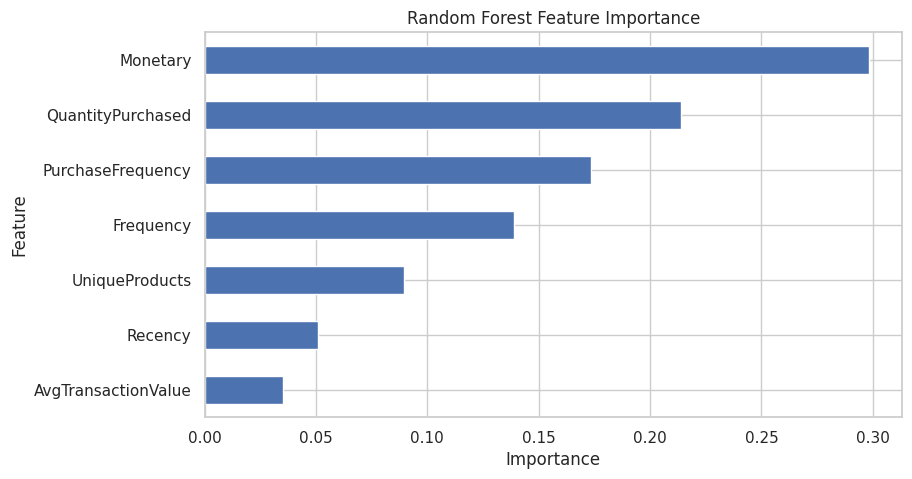

,Importance
Monetary,0.298264
QuantityPurchased,0.213704
PurchaseFrequency,0.173596
Frequency,0.138710
UniqueProducts,0.089729
Recency,0.050937
AvgTransactionValue,0.035060


In [18]:
# 20. Random Forest feature importance
importance = pd.Series(
    rf.feature_importances_,
    index=features
).sort_values(ascending=False)

plt.figure(figsize=(9,5))
importance.sort_values().plot(kind='barh')
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

display(importance.to_frame('Importance'))


## 9. Interactive 3D Visualization using Plotly

In [19]:
# 21. Interactive 3D PCA visualization
pca3 = PCA(n_components=3, random_state=42)
X_pca3 = pca3.fit_transform(X_scaled_df)

customer_model['PCA1_3D'] = X_pca3[:, 0]
customer_model['PCA2_3D'] = X_pca3[:, 1]
customer_model['PCA3_3D'] = X_pca3[:, 2]

fig = px.scatter_3d(
    customer_model,
    x='PCA1_3D',
    y='PCA2_3D',
    z='PCA3_3D',
    color=customer_model['Cluster'].astype(str),
    hover_data=['CustomerID', 'Monetary', 'Frequency', 'Recency'],
    title='Interactive 3D Customer Segmentation'
)

fig.update_layout(
    legend_title_text='Cluster',
    height=700
)

fig.show()


## 10. Segment-wise Marketing Recommendations

The following recommendations should be matched to the actual cluster profiles generated above:

- **High-value / loyal customers:** VIP rewards, early access, premium bundles, loyalty benefits and personalized offers.
- **Frequent but lower-value customers:** cross-selling, product bundles and minimum-order promotions.
- **High monetary but less frequent customers:** personalized reactivation campaigns and reminders.
- **Recent/new customers:** onboarding emails, first-repeat-purchase incentives and product recommendations.
- **Inactive / low-value customers:** win-back campaigns, limited-time discounts and low-cost targeted communication.

The exact cluster interpretation should be based on the displayed cluster profile rather than assuming that a particular cluster number always has the same meaning.


## 11. Final Results Summary

In [20]:
# 22. Automatically generate a concise results summary
print("="*60)
print("FINAL RESULTS")
print("="*60)

print(f"Customers analysed: {len(customer_model):,}")
print(f"Optimal K selected: {optimal_k}")
print(f"K-Means Silhouette Score: {final_silhouette:.4f}")
print(f"High-value cluster: {high_value_cluster}")
print(f"High-value customers: {customer_model['HighValue'].sum():,}")

print("\nModel Performance:")
display(results.round(4))

print("\nPCA variance explained:")
print(f"PC1: {explained[0]*100:.2f}%")
print(f"PC2: {explained[1]*100:.2f}%")
print(f"PC1 + PC2: {explained.sum()*100:.2f}%")


FINAL RESULTS
Customers analysed: 4,338
Optimal K selected: 2
K-Means Silhouette Score: 0.3661
High-value cluster: 1
High-value customers: 2,247

Model Performance:


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Random Forest,0.9827,0.9866,0.9800,0.9833,0.9993
1,SVM,0.9631,0.9624,0.9667,0.9645,0.9963



PCA variance explained:
PC1: 62.84%
PC2: 16.45%
PC1 + PC2: 79.29%


## 12. Conclusion

The experiment demonstrates an end-to-end customer analytics pipeline. Transaction data was cleaned by handling missing customer IDs, cancellations and invalid quantity/price values. Customer-level RFM and purchasing behaviour features were created, transformed and standardized.

K-Means clustering was used to identify customer segments, while the Elbow Method and Silhouette Score supported the selection and validation of the clustering structure. Hierarchical clustering was visualized using a dendrogram, and PCA provided a two-dimensional representation of the customer groups.

The cluster with the highest average monetary value was treated as the high-value customer segment. Random Forest and SVM were then trained to predict high-value membership and evaluated using Accuracy, Precision, Recall, F1-Score, ROC-AUC and Confusion Matrix. Random Forest feature importance was used to identify the purchasing variables most useful for the prediction task.

The resulting customer profiles can support targeted marketing strategies such as loyalty rewards, cross-selling, personalized promotions and customer reactivation campaigns.
